In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os, shutil
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

PROJECT_DRIVE = '/content/drive/MyDrive/PlantDiseaseProject'
LOCAL_DATA = '/content/data'

# Check if PlantVillage is present
pv_path = os.path.join(LOCAL_DATA, 'PlantVillage')
need_unzip = not (
    os.path.exists(pv_path) and
    len([d for d in os.listdir(pv_path) if os.path.isdir(os.path.join(pv_path, d))]) > 30
)

if need_unzip:
    print("Re-unzipping PlantVillage to /content/data...")
    if os.path.exists(pv_path):
        shutil.rmtree(pv_path)
    os.makedirs(pv_path, exist_ok=True)

    !unzip -q "$PROJECT_DRIVE/plantvillage-dataset.zip" -d "$LOCAL_DATA/PlantVillage"

    # Flatten: /content/data/PlantVillage/plantvillage dataset/color/*  →  /content/data/PlantVillage/*
    pv_nested = os.path.join(LOCAL_DATA, 'PlantVillage', 'plantvillage dataset')
    if os.path.exists(pv_nested):
        color_path = os.path.join(pv_nested, 'color')
        source = color_path if os.path.exists(color_path) else pv_nested
        for item in os.listdir(source):
            shutil.move(os.path.join(source, item),
                        os.path.join(LOCAL_DATA, 'PlantVillage', item))
        print("✅ Flattened PlantVillage")
    print("✅ Unzip complete")
else:
    print("✅ PlantVillage already present locally")

# Verify the path referenced in test.csv now exists
import pandas as pd
test_df = pd.read_csv(os.path.join(PROJECT_DRIVE, 'results', 'splits', 'test.csv'))
first_path = test_df.iloc[0]['filepath']
print(f"\nChecking: {first_path}")
print(f"Exists? {os.path.exists(first_path)}")

Re-unzipping PlantVillage to /content/data...
✅ Flattened PlantVillage
✅ Unzip complete

Checking: /content/data/PlantVillage/Apple___Black_rot/52a259e0-e323-4655-84e5-4588cb1c8ed6___JR_FrgE.S 2758.JPG
Exists? True


In [5]:
import pandas as pd, os
test_df = pd.read_csv('/content/drive/MyDrive/PlantDiseaseProject/results/splits/test.csv')
print("Columns:", test_df.columns.tolist())
print("\nFirst row:")
print(test_df.iloc[0])
print("\nPath exists?:", os.path.exists(test_df.iloc[0]['filepath']))
print("Data dir contents:", os.listdir('/content/data') if os.path.exists('/content/data') else "MISSING")

Columns: ['filepath', 'label']

First row:
filepath    /content/data/PlantVillage/Apple___Black_rot/5...
label                                       Apple___Black_rot
Name: 0, dtype: object

Path exists?: True
Data dir contents: ['PlantVillage']


✅ PlantVillage root: /content/data/PlantVillage
✅ Test set: 5431 images, 38 classes
--- CUSTOM_CNN ---
   Macro ROC-AUC:    1.0000
   Weighted ROC-AUC: 1.0000
   Inference:        1.89 ms/img

--- RESNET50 ---
   ✅ Weights loaded via load_weights()
   Macro ROC-AUC:    0.9999
   Weighted ROC-AUC: 0.9999
   Inference:        6.52 ms/img

--- MOBILENETV2 ---
   Macro ROC-AUC:    0.9996
   Weighted ROC-AUC: 0.9996
   Inference:        6.05 ms/img

--- EFFICIENTNETB0 ---
   Macro ROC-AUC:    0.9999
   Weighted ROC-AUC: 0.9999
   Inference:        5.70 ms/img



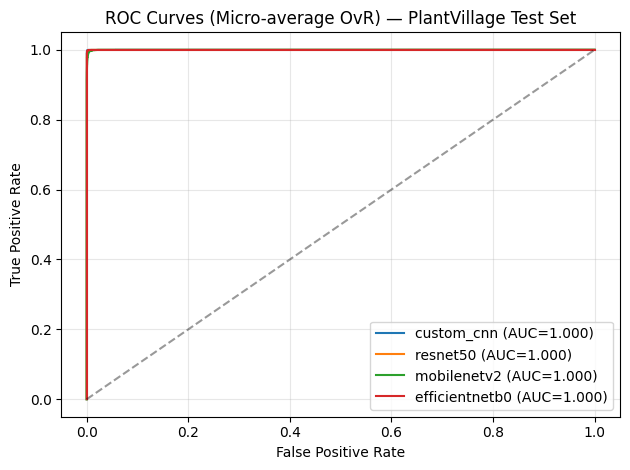


✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/metrics/roc_auc_all_models.json
{
  "custom_cnn": {
    "macro_roc_auc": 0.9999661743073728,
    "weighted_roc_auc": 0.9999735181309801,
    "inference_ms_per_image": 1.885597184753137
  },
  "resnet50": {
    "macro_roc_auc": 0.9999139752931139,
    "weighted_roc_auc": 0.9999347475991358,
    "inference_ms_per_image": 6.519562718267271
  },
  "mobilenetv2": {
    "macro_roc_auc": 0.9995819142316532,
    "weighted_roc_auc": 0.9996097105002624,
    "inference_ms_per_image": 6.054644469638881
  },
  "efficientnetb0": {
    "macro_roc_auc": 0.9998991036795369,
    "weighted_roc_auc": 0.9999261667719502,
    "inference_ms_per_image": 5.703298498135073
  }
}


In [7]:
import os, json, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
SPLIT_DIR   = os.path.join(PROJECT_DIR, 'results', 'splits')
MODELS_DIR  = os.path.join(PROJECT_DIR, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_DIR, 'results', 'metrics')
FIG_DIR     = os.path.join(PROJECT_DIR, 'results', 'figures')
LOCAL_DATA  = '/content/data'
IMG_SIZE, BATCH_SIZE = 224, 32

tf.keras.config.enable_unsafe_deserialization()

# ---------- Locate real PlantVillage root ----------
pv_candidates = [
    os.path.join(LOCAL_DATA, 'PlantVillage'),
    os.path.join(LOCAL_DATA, 'PlantVillage', 'plantvillage dataset', 'color'),
    os.path.join(LOCAL_DATA, 'PlantVillage', 'plantvillage dataset'),
]
real_root = None
for c in pv_candidates:
    if os.path.exists(c):
        dirs = [d for d in os.listdir(c) if os.path.isdir(os.path.join(c, d))]
        if len(dirs) > 30:
            real_root = c
            break
assert real_root is not None
print(f"✅ PlantVillage root: {real_root}")

# ---------- Load splits ----------
test_df  = pd.read_csv(os.path.join(SPLIT_DIR, 'test.csv'))
class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
class_to_idx = dict(zip(class_df['class'], class_df['index']))
class_names  = [k for k, v in sorted(class_to_idx.items(), key=lambda x: x[1])]
NUM_CLASSES  = len(class_to_idx)

def rebuild_path(p):
    parts = p.split('/PlantVillage/')[-1].split('/')
    if parts[0] == 'plantvillage dataset':
        parts = parts[2:]
    return os.path.join(real_root, *parts)

test_df['filepath'] = test_df['filepath'].apply(rebuild_path)

# ---------- Dataset builder ----------
def decode_img(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, NUM_CLASSES)

def make_ds(df):
    paths  = df['filepath'].values
    labels = df['label'].map(class_to_idx).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = make_ds(test_df)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
print(f"✅ Test set: {len(y_true)} images, {len(np.unique(y_true))} classes")

# ============================================================
# ResNet50 rebuild helper (fixes Lambda output_shape problem)
# ============================================================
def build_resnet50(num_classes):
    """Rebuild ResNet50 architecture with an explicit named preprocess function."""
    def preprocess_resnet50(x):
        return tf.keras.applications.resnet50.preprocess_input(x * 255.0)

    base = tf.keras.applications.ResNet50(
        weights=None, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Lambda(preprocess_resnet50,
                      output_shape=(IMG_SIZE, IMG_SIZE, 3),
                      name='preprocess')(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='resnet50')

# ============================================================
# Evaluation loop (with ResNet50 special handling)
# ============================================================
roc_results = {}
for model_name in ['custom_cnn', 'resnet50', 'mobilenetv2', 'efficientnetb0']:
    model_path = os.path.join(MODELS_DIR, f'{model_name}.keras')
    if not os.path.exists(model_path):
        print(f"❌ {model_name}: not found"); continue

    print(f"--- {model_name.upper()} ---")

    if model_name == 'resnet50':
        # Special path: rebuild + load weights
        model = build_resnet50(NUM_CLASSES)
        try:
            model.load_weights(model_path)
            print("   ✅ Weights loaded via load_weights()")
        except Exception as e:
            print(f"   ⚠️ load_weights failed: {e}")
            import zipfile, tempfile
            with tempfile.TemporaryDirectory() as tmp:
                with zipfile.ZipFile(model_path, 'r') as z:
                    z.extractall(tmp)
                wf = os.path.join(tmp, 'model.weights.h5')
                if os.path.exists(wf):
                    model.load_weights(wf)
                    print("   ✅ Weights loaded from archive")
    else:
        model = tf.keras.models.load_model(model_path, safe_mode=False)

    t0 = time.time()
    y_prob = model.predict(test_ds, verbose=0)
    inf_ms = (time.time() - t0) / len(y_true) * 1000

    macro_auc    = roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='macro')
    weighted_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='weighted')

    roc_results[model_name] = {
        'macro_roc_auc':    float(macro_auc),
        'weighted_roc_auc': float(weighted_auc),
        'inference_ms_per_image': float(inf_ms),
    }
    print(f"   Macro ROC-AUC:    {macro_auc:.4f}")
    print(f"   Weighted ROC-AUC: {weighted_auc:.4f}")
    print(f"   Inference:        {inf_ms:.2f} ms/img\n")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={macro_auc:.3f})')

# ---------- Combined ROC figure ----------
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Micro-average OvR) — PlantVillage Test Set')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'roc_curves_plantvillage.png'), dpi=150, bbox_inches='tight')
plt.show()

with open(os.path.join(METRICS_DIR, 'roc_auc_all_models.json'), 'w') as f:
    json.dump(roc_results, f, indent=2)
print(f"\n✅ Saved: {METRICS_DIR}/roc_auc_all_models.json")
print(json.dumps(roc_results, indent=2))